# Análisis comparativo de los modelos entrenados

**Experimento:** `20260809_004420` · partición semilla 42 · nueve corridas
**Documento hermano:** [`analisis-mobilenetv2.ipynb`](analisis-mobilenetv2.ipynb),
que analiza el modelo **desplegado** y motivó este experimento.

Aquel cuaderno terminó con un diagnóstico: el MobileNetV2 en producción daba
98,43 % en su propio dataset y **71,60 %** con la cámara del robot. Este
documento evalúa la corrección: reconstruir el dataset y reentrenar tres
arquitecturas para ver cuánto de esa brecha se cierra.

## Contenido

1. Qué se compara y por qué esas tres arquitecturas
2. Los datos y su partición inmutable
3. Diseño experimental
4. Resultados de validación
5. Comportamiento durante el entrenamiento
6. Verificación de cuantización (criterio 4)
7. Criterios de aceptación y recomendación

### Cómo ejecutar este cuaderno

Requiere `requirements-dev.txt` y lee los artefactos ligeros de
`resultados-vision/2026-08-09/` (incluida junto a este cuaderno). No necesita el dataset ni los pesos.

## 0. Preparación del entorno

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

# ── Paleta ────────────────────────────────────────────────────────────────
# Validada para las tres formas de daltonismo (deuteranopía, protanopía,
# tritanopía) antes de usarse: el peor par mide ΔE 24,7, muy por encima del
# umbral de 8. El color nunca es el único canal: todas las barras van rotuladas.
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
APAGADO, REJILLA, BASE     = "#898781", "#e1e0d9", "#c3c2b7"

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # slots categóricos 1-3
CRITICO, BUENO      = "#d03b3b", "#0ca30c"              # estados

RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Divergente para correlaciones: rojo (negativa) ← gris (nula) → azul (positiva)
RAMPA_DIV  = ["#8c2020", "#d03b3b", "#e89a9a", "#f0efec", "#9ec5f4", "#2a78d6", "#104281"]

CMAP_SEC = LinearSegmentedColormap.from_list("azul", RAMPA_AZUL)
CMAP_DIV = LinearSegmentedColormap.from_list("div", RAMPA_DIV)

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10, "text.color": TINTA,
    "axes.labelcolor": TINTA_2, "axes.edgecolor": BASE, "axes.linewidth": 0.8,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlepad": 12, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8,
    "xtick.color": APAGADO, "ytick.color": APAGADO,
    "xtick.labelcolor": TINTA_2, "ytick.labelcolor": TINTA_2,
    "legend.frameon": False, "figure.dpi": 110,
})


def limpiar(ax, eje_y=True):
    """Marco recesivo: sin bordes superior/derecho, rejilla en un solo eje."""
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(BASE)
    ax.spines["bottom"].set_color(BASE)
    ax.xaxis.grid(not eje_y)
    ax.yaxis.grid(eje_y)
    ax.tick_params(length=0)
    return ax


def poner_titulo(ax, texto, subtitulo=""):
    """Título con subtítulo debajo. Las distancias van en puntos tipográficos,
    no en fracción de eje, para que no se solapen a ninguna altura de figura."""
    ax.set_title(texto, loc="left", pad=30 if subtitulo else 12)
    if subtitulo:
        ax.annotate(subtitulo, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 10), textcoords="offset points",
                    ha="left", va="bottom", color=TINTA_2, fontsize=10)


def matriz_confusion(ax, cm, clases, titulo, subtitulo=""):
    """Mapa de calor de una matriz de confusión (rampa secuencial de un tono)."""
    pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(pct, cmap=CMAP_SEC, vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}\n{pct[i, j]*100:.1f} %",
                    ha="center", va="center", fontsize=11,
                    color="#ffffff" if pct[i, j] > 0.55 else TINTA,
                    fontweight="bold" if i == j else "normal")
    ax.set_xticks(range(len(clases)), [f"predijo\n{c}" for c in clases])
    ax.set_yticks(range(len(clases)), [f"real\n{c}" for c in clases])
    poner_titulo(ax, titulo, subtitulo)
    ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)


MODELO_DIR = Path.cwd()
if MODELO_DIR.name != "model":
    MODELO_DIR = next((p for p in (Path("ia/vision-service/model"), Path("model"))
                       if p.exists()), MODELO_DIR)

print("Carpeta del modelo:", MODELO_DIR.resolve())
print("Archivos:", sorted(p.name for p in MODELO_DIR.glob("*") if p.is_file()))

Carpeta del modelo: /Users/hernandezaxel/Pau/Reci/graficos-andrea
Archivos: ['GUIA-GRAFICAS-FERIA.md', 'analisis-modelos-entrenados.ipynb']


In [2]:
from pathlib import Path
import csv, json

CANDIDATOS_RESULTADOS = [
    Path("resultados-vision/2026-08-09"),
    Path("graficos-andrea/resultados-vision/2026-08-09"),
]
RESULTADOS = next((p for p in CANDIDATOS_RESULTADOS if p.is_dir()), None)
if RESULTADOS is None:
    raise SystemExit("No se encuentran resultados-vision/2026-08-09 junto al cuaderno.")

with (RESULTADOS / "resumen_comparacion.csv").open(encoding="utf-8", newline="") as fh:
    CORRIDAS = list(csv.DictReader(fh))
ESTADISTICO = json.loads((RESULTADOS / "resumen_estadistico.json").read_text(encoding="utf-8"))
GANADOR = json.loads((RESULTADOS / "ganador_validacion.json").read_text(encoding="utf-8"))

ARQ = ["mobilenetv2", "efficientnetb0", "mobilenetv3large"]
NOMBRE = {"mobilenetv2": "MobileNetV2", "efficientnetb0": "EfficientNet-B0",
          "mobilenetv3large": "MobileNetV3-Large"}
COLOR = {"mobilenetv2": AZUL, "efficientnetb0": APAGADO, "mobilenetv3large": NARANJA}

def stat(arq, metrica, campo="media"):
    fila = next(e for e in ESTADISTICO if e["arquitectura"] == arq)
    return fila["estadisticas_validacion"][metrica][campo]

def metricas_de(run_id):
    ruta = RESULTADOS / "metricas" / f"{run_id}_validacion_metricas.json"
    return json.loads(ruta.read_text(encoding="utf-8"))

PRESENTACION_RUN = max((r for r in CORRIDAS if r["arquitectura"] == "mobilenetv2"),
                       key=lambda r: float(r["val_macro_f1"]))
print(f"{len(CORRIDAS)} corridas cargadas desde {RESULTADOS.resolve()}")
print(f"Ganador experimental por validación: {GANADOR['ganador']['run_id']}")
print("Modelo operativo actual: MobileNetV2 float32 run_20260721_2129")


9 corridas cargadas desde /Users/hernandezaxel/Pau/Reci/graficos-andrea/resultados-vision/2026-08-09
Ganador experimental por validación: mobilenetv3large_20260809_004420_split42_seed1
Modelo operativo actual: MobileNetV2 float32 run_20260721_2129


# Figuras núcleo para la feria

Las siguientes ocho figuras son la versión breve para exposición. Usan el
estado operativo actual y la evidencia reproducible que está incluida en
`resultados-vision/2026-08-09/`. El experimento de nueve corridas se
mantiene después como respaldo técnico.


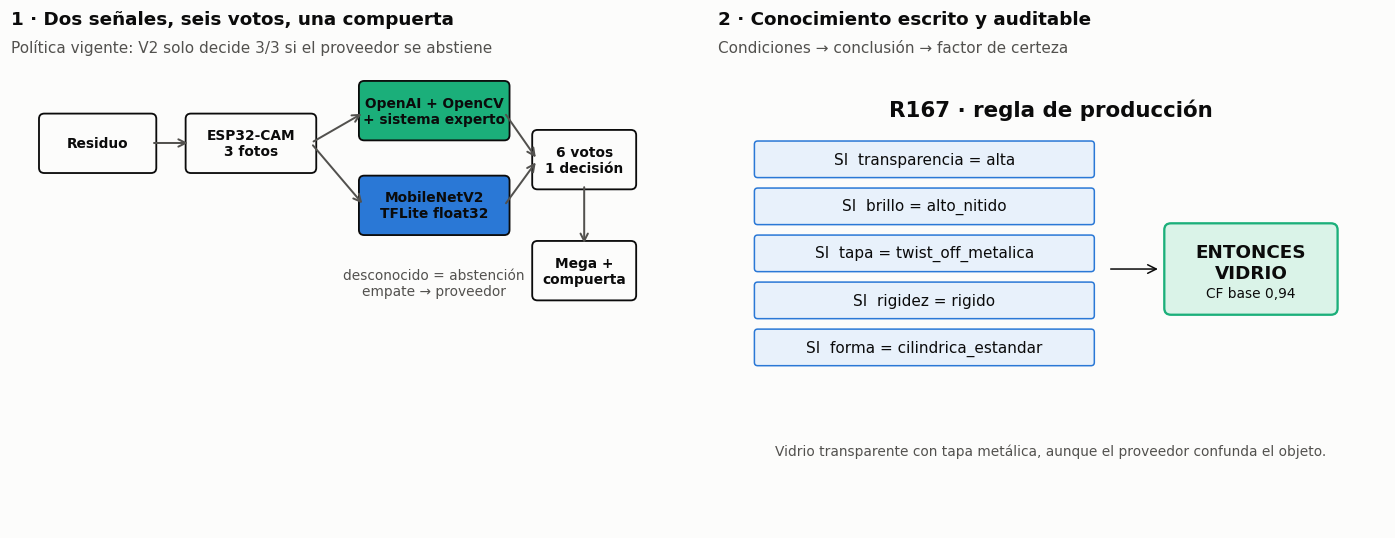

In [3]:
# 1. Diagrama del sistema completo · 2. Anatomía de una regla real.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.set_axis_off(); ax1.set_xlim(0, 10); ax1.set_ylim(0, 7)
cajas = [(0.5, 5.5, 1.6, 0.75, "Residuo"), (2.7, 5.5, 1.8, 0.75, "ESP32-CAM\n3 fotos"),
         (5.3, 6.0, 2.1, 0.75, "OpenAI + OpenCV\n+ sistema experto"),
         (5.3, 4.55, 2.1, 0.75, "MobileNetV2\nTFLite float32"),
         (7.9, 5.25, 1.4, 0.75, "6 votos\n1 decisión"),
         (7.9, 3.55, 1.4, 0.75, "Mega +\ncompuerta")]
for x, y, w, h, label in cajas:
    color = AQUA if "experto" in label else AZUL if "Mobile" in label else SUPERFICIE
    ax1.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=.08", fc=color, ec=TINTA, lw=1.2))
    ax1.text(x+w/2, y+h/2, label, ha="center", va="center", fontsize=9, weight="bold")
flechas = [((2.1,5.88),(2.7,5.88)), ((4.5,5.88),(5.3,6.35)), ((4.5,5.88),(5.3,4.92)),
           ((7.4,6.35),(7.9,5.62)), ((7.4,4.92),(7.9,5.62)), ((8.6,5.25),(8.6,4.3))]
for a, b in flechas: ax1.add_patch(FancyArrowPatch(a, b, arrowstyle="->", mutation_scale=12, lw=1.3, color=TINTA_2))
ax1.text(6.35, 3.55, "desconocido = abstención\nempate → proveedor", ha="center", fontsize=9, color=TINTA_2)
poner_titulo(ax1, "1 · Dos señales, seis votos, una compuerta", "Política vigente: V2 solo decide 3/3 si el proveedor se abstiene")

ax2.set_axis_off(); ax2.set_xlim(0, 10); ax2.set_ylim(0, 7)
ax2.text(5, 6.3, "R167 · regla de producción", ha="center", weight="bold", fontsize=14)
condiciones = ["transparencia = alta", "brillo = alto_nitido", "tapa = twist_off_metalica", "rigidez = rigido", "forma = cilindrica_estandar"]
for i, condicion in enumerate(condiciones):
    y = 5.4 - i*.72
    ax2.add_patch(FancyBboxPatch((.6,y), 5.0,.46, boxstyle="round,pad=.05", fc="#e8f1fb", ec=AZUL))
    ax2.text(3.1,y+.23,"SI  " + condicion,ha="center",va="center",fontsize=10)
ax2.add_patch(FancyArrowPatch((5.85,3.95),(6.65,3.95),arrowstyle="->",mutation_scale=14,color=TINTA))
ax2.add_patch(FancyBboxPatch((6.8,3.35),2.4,1.2,boxstyle="round,pad=.1",fc="#daf3e8",ec=AQUA,lw=1.5))
ax2.text(8,4.05,"ENTONCES\nVIDRIO",ha="center",va="center",fontsize=12,weight="bold")
ax2.text(8,3.58,"CF base 0,94",ha="center",va="center",fontsize=9)
ax2.text(5,1.1,"Vidrio transparente con tapa metálica, aunque el proveedor confunda el objeto.",ha="center",fontsize=9,color=TINTA_2)
poner_titulo(ax2, "2 · Conocimiento escrito y auditable", "Condiciones → conclusión → factor de certeza")
plt.tight_layout(); plt.show()


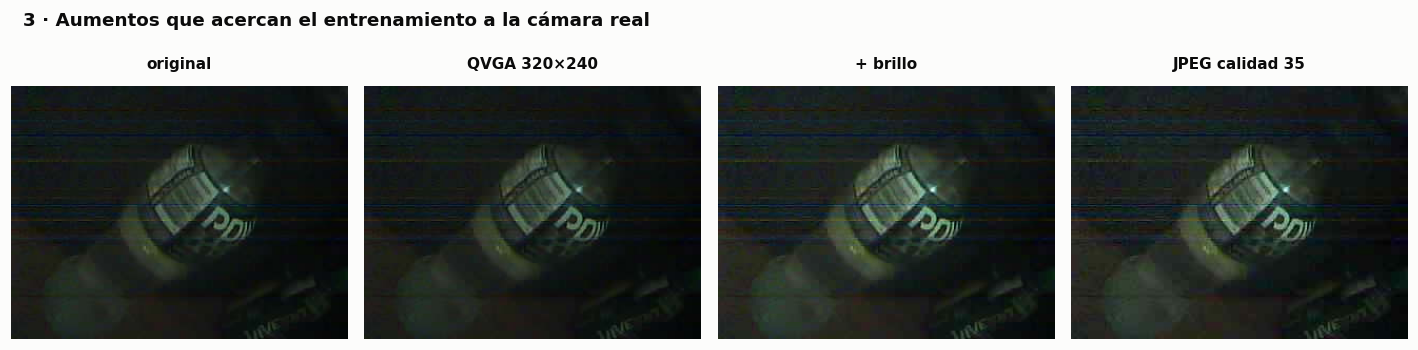

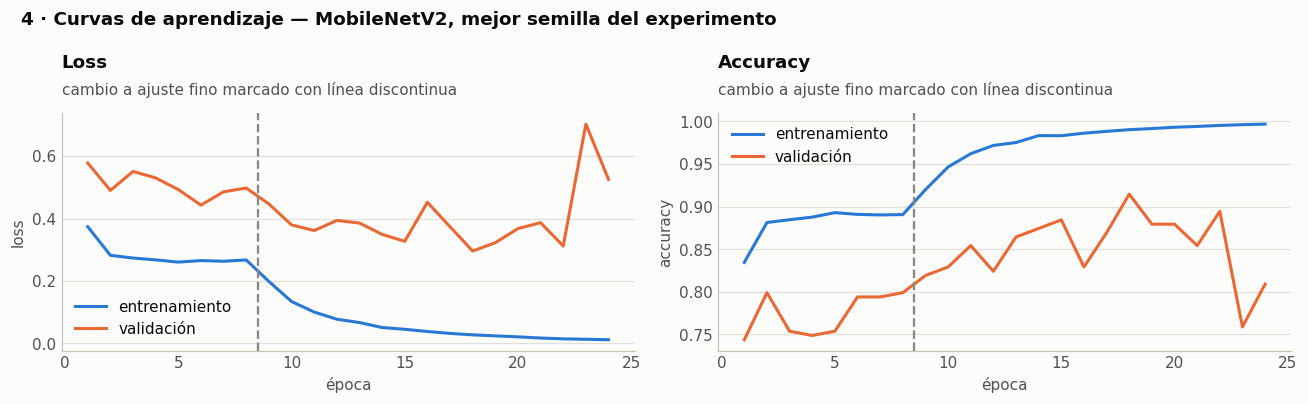

In [4]:
# 3. Aumentos con captura real · 4. Curvas de aprendizaje de la mejor corrida V2.
from PIL import Image, ImageEnhance
from io import BytesIO

FOTO = next((p for p in [Path("ia/vision-service/dataset-esp32cam/plastico/plastico_20260724_084224_019.jpg"),
                          Path("../ia/vision-service/dataset-esp32cam/plastico/plastico_20260724_084224_019.jpg")]
             if p.is_file()), None)
if FOTO is None: raise FileNotFoundError("No se encontró la captura ESP32-CAM para la figura de aumentos.")
original = Image.open(FOTO).convert("RGB")
qvga = original.resize((320, 240))
brillo = ImageEnhance.Brightness(qvga).enhance(1.35)
buffer = BytesIO(); brillo.save(buffer, format="JPEG", quality=35); jpeg = Image.open(BytesIO(buffer.getvalue()))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, image, label in zip(axes, [original, qvga, brillo, jpeg], ["original", "QVGA 320×240", "+ brillo", "JPEG calidad 35"]):
    ax.imshow(image); ax.set_title(label, fontsize=10); ax.axis("off")
fig.suptitle("3 · Aumentos que acercan el entrenamiento a la cámara real", x=.02, ha="left", weight="bold")
plt.tight_layout(); plt.show()

ruta = RESULTADOS / "historiales" / f"{PRESENTACION_RUN['run_id']}_history.csv"
with ruta.open(encoding="utf-8", newline="") as fh: historia = list(csv.DictReader(fh))
ep = [int(f["epoch"]) for f in historia]; corte = sum(f["fase"] == "cabeza" for f in historia)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.7))
for ax, a, b, titulo in [(axes[0], "loss", "val_loss", "loss"), (axes[1], "accuracy", "val_accuracy", "accuracy")]:
    ax.plot(ep, [float(f[a]) for f in historia], label="entrenamiento", color=AZUL, lw=2)
    ax.plot(ep, [float(f[b]) for f in historia], label="validación", color=NARANJA, lw=2)
    ax.axvline(ep[corte-1]+.5, ls="--", color=APAGADO); ax.set(xlabel="época", ylabel=titulo)
    ax.legend(); limpiar(ax); poner_titulo(ax, titulo.capitalize(), "cambio a ajuste fino marcado con línea discontinua")
fig.suptitle("4 · Curvas de aprendizaje — MobileNetV2, mejor semilla del experimento", x=.02, ha="left", weight="bold")
plt.tight_layout(); plt.show()


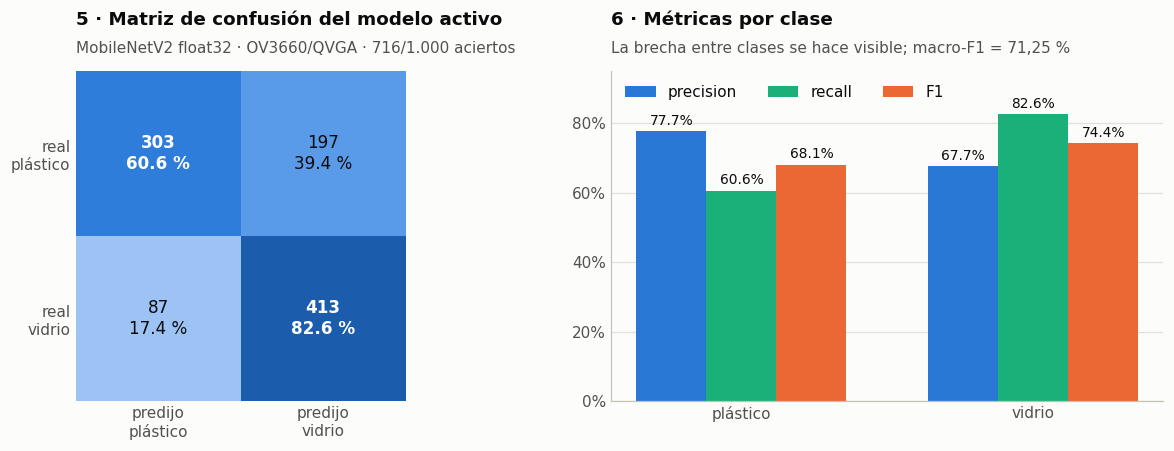

In [5]:
# 5. Matriz operativa del activo · 6. Precision, recall y F1 por clase.
matriz = np.array([[303, 197], [87, 413]])  # evaluación OV3660/QVGA, 1.000 capturas
clases = ["plástico", "vidrio"]
precision = [303/(303+87), 413/(413+197)]
recall = [303/500, 413/500]
f1 = [2*p*r/(p+r) for p, r in zip(precision, recall)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
matriz_confusion(ax1, matriz, clases, "5 · Matriz de confusión del modelo activo", "MobileNetV2 float32 · OV3660/QVGA · 716/1.000 aciertos")
x = np.arange(2); ancho=.24
for off, valores, etiqueta, color in [(-ancho, precision, "precision", AZUL), (0, recall, "recall", AQUA), (ancho, f1, "F1", NARANJA)]:
    barras=ax2.bar(x+off, valores, ancho, label=etiqueta, color=color)
    for barra, valor in zip(barras, valores): ax2.text(barra.get_x()+barra.get_width()/2, valor+.018, f"{valor:.1%}", ha="center", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(clases); ax2.set_ylim(0,.95); ax2.yaxis.set_major_formatter(PercentFormatter(1.0)); ax2.legend(ncol=3)
limpiar(ax2); poner_titulo(ax2, "6 · Métricas por clase", "La brecha entre clases se hace visible; macro-F1 = 71,25 %")
plt.tight_layout(); plt.show()


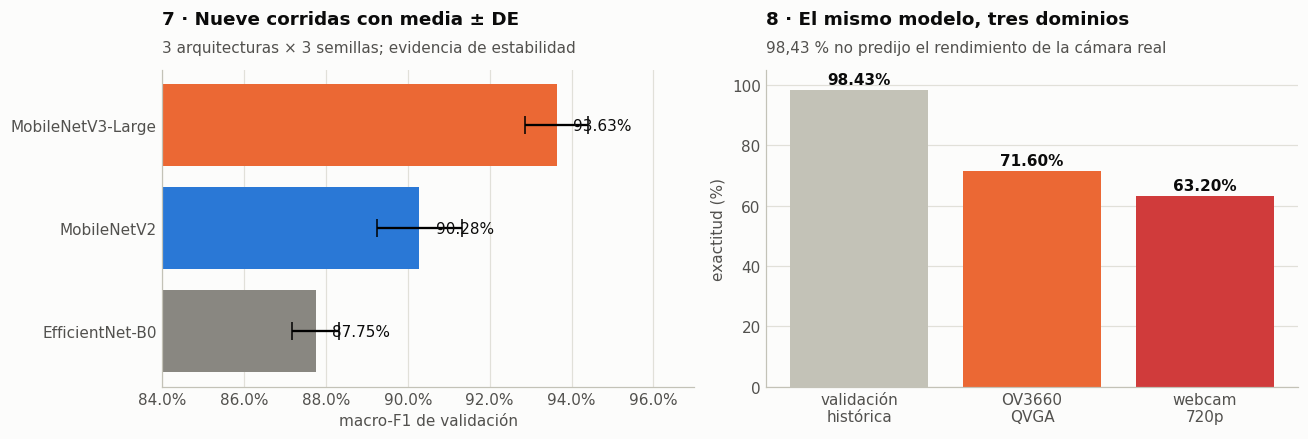

In [6]:
# 7. Nueve corridas · 8. Tres dominios del modelo activo.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))
orden = np.argsort([stat(a, "val_macro_f1") for a in ARQ]); y=np.arange(3)
medias=[stat(ARQ[i], "val_macro_f1") for i in orden]; desv=[stat(ARQ[i], "val_macro_f1", "desviacion_estandar") for i in orden]
barras=ax1.barh(y, medias, xerr=desv, capsize=6, color=[COLOR[ARQ[i]] for i in orden])
ax1.set_yticks(y); ax1.set_yticklabels([NOMBRE[ARQ[i]] for i in orden]); ax1.set_xlim(.84,.97); ax1.xaxis.set_major_formatter(PercentFormatter(1.0)); ax1.set_xlabel("macro-F1 de validación")
for bar, value in zip(barras, medias): ax1.text(value+.004, bar.get_y()+bar.get_height()/2, f"{value:.2%}", va="center")
limpiar(ax1, eje_y=False); poner_titulo(ax1, "7 · Nueve corridas con media ± DE", "3 arquitecturas × 3 semillas; evidencia de estabilidad")

dominios=["validación\nhistórica", "OV3660\nQVGA", "webcam\n720p"]; valores=[98.43, 71.60, 63.2]
bars=ax2.bar(dominios, valores, color=[BASE, NARANJA, CRITICO])
ax2.set_ylim(0,105); ax2.set_ylabel("exactitud (%)")
for bar, value in zip(bars,valores): ax2.text(bar.get_x()+bar.get_width()/2,value+2,f"{value:.2f}%",ha="center",weight="bold")
limpiar(ax2); poner_titulo(ax2, "8 · El mismo modelo, tres dominios", "98,43 % no predijo el rendimiento de la cámara real")
plt.tight_layout(); plt.show()


# Figuras complementarias solicitadas por la guía

Para identificarlas sin ambigüedad:

| Número en el notebook | Gráfica de la guía | Qué debes señalar al explicarla |
| ---: | --- | --- |
| **9** | 193 reglas → 5 conclusiones | Muchas reglas, pero solo cinco resultados simbólicos |
| **10** | Motor de inferencia | Validación → meta-reglas → forward/CF → backward → política A2 |
| **11** | Partición por sesión | Ninguna sesión se divide entre entrenamiento, validación y prueba |
| **12** | Regresión por cuantización | El TFLite INT8 puede comportarse distinto al Keras float32 |
| **13** | Capacidad de rechazo | El modelo binario no puede abstenerse; el sistema experto sí |

Las figuras 9–13 complementan las ocho del núcleo que aparecen arriba.


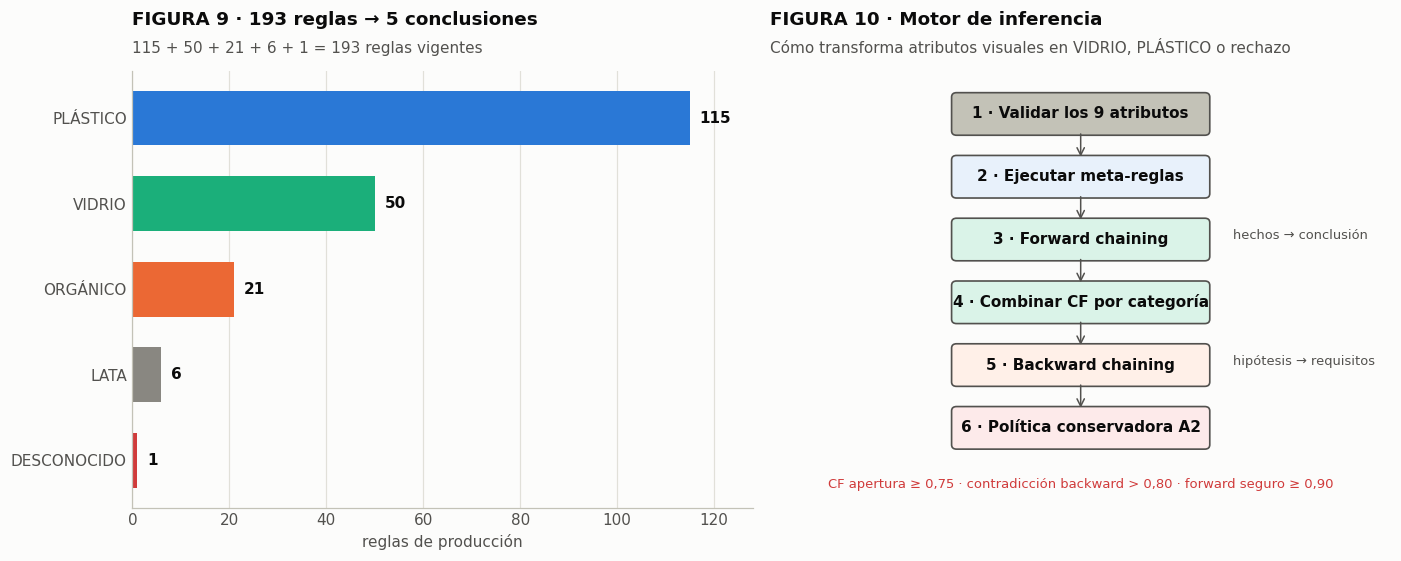

In [7]:
# FIGURA 9 · Distribución de 193 reglas — FIGURA 10 · Motor de inferencia.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

categorias = ["PLÁSTICO", "VIDRIO", "ORGÁNICO", "LATA", "DESCONOCIDO"]
cantidades = [115, 50, 21, 6, 1]
colores = [AZUL, AQUA, NARANJA, APAGADO, CRITICO]
y = np.arange(len(categorias))
barras = ax1.barh(y, cantidades, color=colores, height=.64)
ax1.set_yticks(y); ax1.set_yticklabels(categorias); ax1.invert_yaxis()
ax1.set_xlim(0, 128); ax1.set_xlabel("reglas de producción")
for barra, valor in zip(barras, cantidades):
    ax1.text(valor + 2, barra.get_y() + barra.get_height()/2, str(valor), va="center", weight="bold")
limpiar(ax1, eje_y=False)
poner_titulo(ax1, "FIGURA 9 · 193 reglas → 5 conclusiones", "115 + 50 + 21 + 6 + 1 = 193 reglas vigentes")

ax2.set_axis_off(); ax2.set_xlim(0, 10); ax2.set_ylim(0, 8)
pasos = [
    (3.0, 6.9, 4.0, .62, "1 · Validar los 9 atributos", BASE),
    (3.0, 5.75, 4.0, .62, "2 · Ejecutar meta-reglas", "#e8f1fb"),
    (3.0, 4.6, 4.0, .62, "3 · Forward chaining", "#daf3e8"),
    (3.0, 3.45, 4.0, .62, "4 · Combinar CF por categoría", "#daf3e8"),
    (3.0, 2.3, 4.0, .62, "5 · Backward chaining", "#fff0e8"),
    (3.0, 1.15, 4.0, .62, "6 · Política conservadora A2", "#fdeaea"),
]
for x, y0, w, h, texto, color in pasos:
    ax2.add_patch(FancyBboxPatch((x,y0),w,h,boxstyle="round,pad=.08",fc=color,ec=TINTA_2,lw=1.1))
    ax2.text(x+w/2,y0+h/2,texto,ha="center",va="center",fontsize=10,weight="bold")
for (_, y0, _, h, _, _), (_, y1, _, _, _, _) in zip(pasos, pasos[1:]):
    ax2.add_patch(FancyArrowPatch((5,y0),(5,y1+h),arrowstyle="->",mutation_scale=12,color=TINTA_2))
ax2.text(7.45, 4.92, "hechos → conclusión", fontsize=8.5, color=TINTA_2)
ax2.text(7.45, 2.62, "hipótesis → requisitos", fontsize=8.5, color=TINTA_2)
ax2.text(5, .35, "CF apertura ≥ 0,75 · contradicción backward > 0,80 · forward seguro ≥ 0,90", ha="center", fontsize=8.6, color=CRITICO)
poner_titulo(ax2, "FIGURA 10 · Motor de inferencia", "Cómo transforma atributos visuales en VIDRIO, PLÁSTICO o rechazo")
plt.tight_layout(); plt.show()


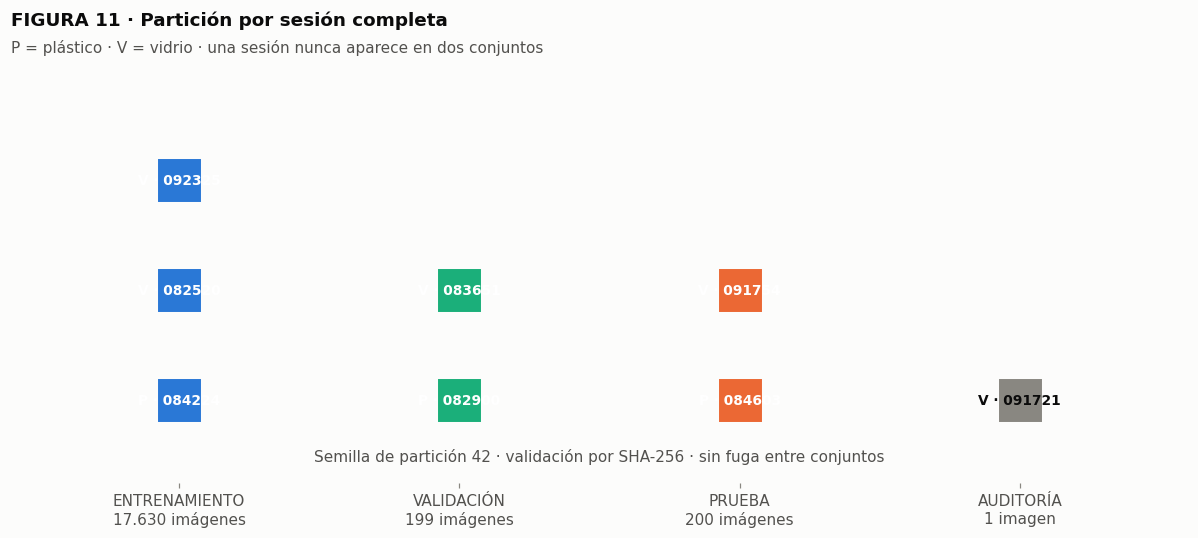

In [8]:
# FIGURA 11 · Las ocho sesiones completas y su partición inmutable.
sesiones = [
    ("P · 084224", "entrenamiento"),
    ("V · 082520", "entrenamiento"),
    ("V · 092325", "entrenamiento"),
    ("P · 082900", "validación"),
    ("V · 083651", "validación"),
    ("P · 084603", "prueba"),
    ("V · 091754", "prueba"),
    ("V · 091721", "auditoría"),
]
grupos = ["entrenamiento", "validación", "prueba", "auditoría"]
color_grupo = {"entrenamiento": AZUL, "validación": AQUA, "prueba": NARANJA, "auditoría": APAGADO}
x_grupo = {grupo: i for i, grupo in enumerate(grupos)}
fig, ax = plt.subplots(figsize=(11, 5.0))
niveles = {grupo: 0 for grupo in grupos}
for nombre, grupo in sesiones:
    nivel = niveles[grupo]; niveles[grupo] += 1
    x = x_grupo[grupo]
    ax.scatter(x, nivel, s=900, marker="s", color=color_grupo[grupo], edgecolor=SUPERFICIE, linewidth=2)
    ax.text(x, nivel, nombre, ha="center", va="center", fontsize=9, weight="bold", color="white" if grupo != "auditoría" else TINTA)
ax.set_xticks(range(4)); ax.set_xticklabels(["ENTRENAMIENTO\n17.630 imágenes", "VALIDACIÓN\n199 imágenes", "PRUEBA\n200 imágenes", "AUDITORÍA\n1 imagen"])
ax.set_xlim(-.6, 3.6); ax.set_ylim(-.75, 3.0); ax.set_yticks([]); ax.grid(False)
for lado in ax.spines.values(): lado.set_visible(False)
poner_titulo(ax, "FIGURA 11 · Partición por sesión completa", "P = plástico · V = vidrio · una sesión nunca aparece en dos conjuntos")
ax.text(1.5, -.55, "Semilla de partición 42 · validación por SHA-256 · sin fuga entre conjuntos", ha="center", color=TINTA_2)
plt.tight_layout(); plt.show()


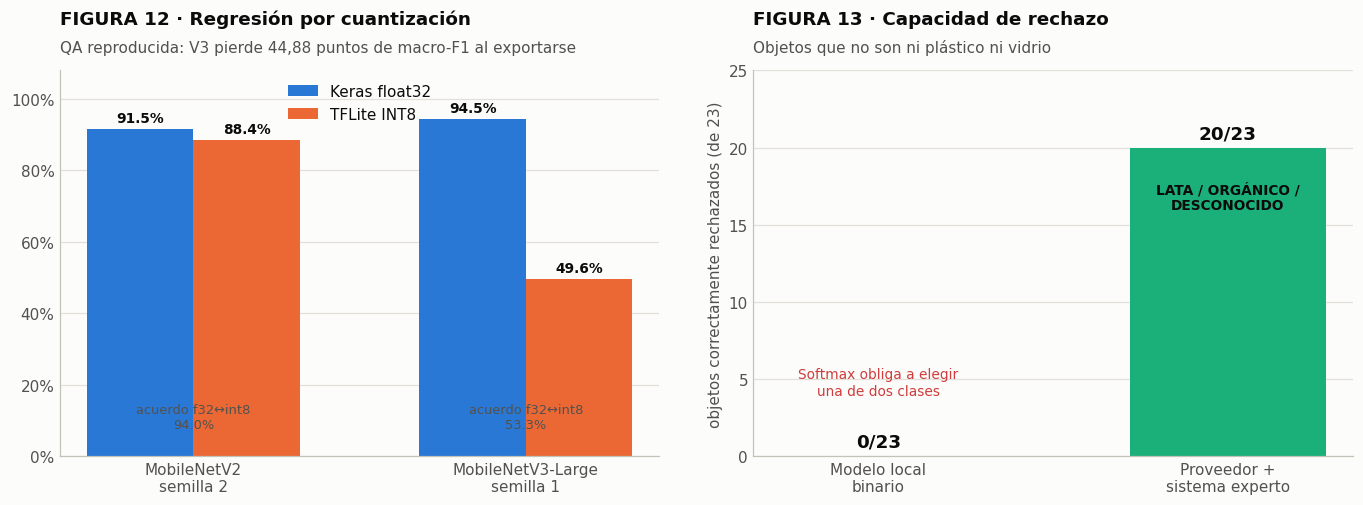

In [9]:
# FIGURA 12 · Regresión por cuantización — FIGURA 13 · Capacidad de rechazo.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.7))

modelos = ["MobileNetV2\nsemilla 2", "MobileNetV3-Large\nsemilla 1"]
keras_f1 = [0.9145, 0.9447]
int8_f1 = [0.8844, 0.4959]
acuerdos = [0.9397, 0.5327]
x = np.arange(2); ancho = .32
b1 = ax1.bar(x-ancho/2, keras_f1, ancho, label="Keras float32", color=AZUL)
b2 = ax1.bar(x+ancho/2, int8_f1, ancho, label="TFLite INT8", color=NARANJA)
ax1.set_xticks(x); ax1.set_xticklabels(modelos); ax1.set_ylim(0,1.08); ax1.yaxis.set_major_formatter(PercentFormatter(1.0)); ax1.legend()
for barras in (b1,b2):
    for barra in barras:
        ax1.text(barra.get_x()+barra.get_width()/2,barra.get_height()+.02,f"{barra.get_height():.1%}",ha="center",fontsize=9,weight="bold")
for i, acuerdo in enumerate(acuerdos):
    ax1.text(i, .08, f"acuerdo f32↔int8\n{acuerdo:.1%}", ha="center", fontsize=8.5, color=TINTA_2)
limpiar(ax1)
poner_titulo(ax1, "FIGURA 12 · Regresión por cuantización", "QA reproducida: V3 pierde 44,88 puntos de macro-F1 al exportarse")

fuentes = ["Modelo local\nbinario", "Proveedor +\nsistema experto"]
rechazo = [0, 20]
bars = ax2.bar(fuentes, rechazo, color=[CRITICO, AQUA], width=.56)
ax2.set_ylim(0,25); ax2.set_ylabel("objetos correctamente rechazados (de 23)")
for bar, value in zip(bars,rechazo):
    ax2.text(bar.get_x()+bar.get_width()/2,value+.6,f"{value}/23",ha="center",weight="bold",fontsize=12)
limpiar(ax2)
poner_titulo(ax2, "FIGURA 13 · Capacidad de rechazo", "Objetos que no son ni plástico ni vidrio")
ax2.text(0, 4, "Softmax obliga a elegir\nuna de dos clases", ha="center", color=CRITICO, fontsize=9)
ax2.text(1, 16, "LATA / ORGÁNICO /\nDESCONOCIDO", ha="center", color=TINTA, fontsize=9, weight="bold")
plt.tight_layout(); plt.show()


# 1. Qué se compara y por qué

## 1.1. El experimento

Tres arquitecturas × tres semillas de entrenamiento = **nueve corridas**, todas
con las mismas particiones, aumentos y presupuesto de ajuste. Esa igualdad es
lo que permite atribuir las diferencias a la arquitectura y no al azar del
procedimiento.

| ID | Arquitectura | Papel |
| --- | --- | --- |
| E1 | MobileNetV2 | **Control** — la arquitectura ya desplegada |
| E2 | EfficientNet-B0 | Candidato principal |
| E3 | MobileNetV3-Large | Candidato eficiente |

E1 es la pieza clave del diseño: al reentrenar la arquitectura actual con los
datos nuevos, separa **cuánta mejora viene de los datos** de cuánta viene de
cambiar de modelo. Sin ese control, cualquier ganancia se atribuiría por
defecto a la arquitectura nueva.

## 1.2. En qué se diferencian las tres

Las tres son redes convolucionales ligeras que parten de pesos de ImageNet
(*transfer learning*). Sus diferencias caben en tres rasgos:

| | MobileNetV2 | EfficientNet-B0 | MobileNetV3-Large |
| --- | --- | --- | --- |
| Parámetros | ≈ 3,5 M | ≈ 5,3 M | ≈ 5,4 M |
| Atención de canales | **No** | Sí (*squeeze-and-excitation*) | Sí |
| Activación | **ReLU6** (acotada) | Swish | hard-swish |
| Diseño | Manual | Escalado compuesto | Búsqueda de arquitectura (NAS) |

La **atención de canales** es la hipótesis del experimento: permite a la red
ponderar qué canales importan en cada región, algo que MobileNetV2 no tiene. Si
distinguir plástico transparente de vidrio depende de reflejos sutiles, debería
ayudar.

La fila de la **activación** parece un detalle técnico menor. En la sección 6
resulta ser decisiva.

# 2. Los datos

## 2.1. Composición

El dataset de trabajo combina dos orígenes, y la diferencia importa:

- **Externas** — el dataset anterior, de otra cámara. Aportan volumen.
- **Sesiones de ESP32-CAM** — capturas de la cámara real del robot. Aportan
  representatividad del dominio de producción.

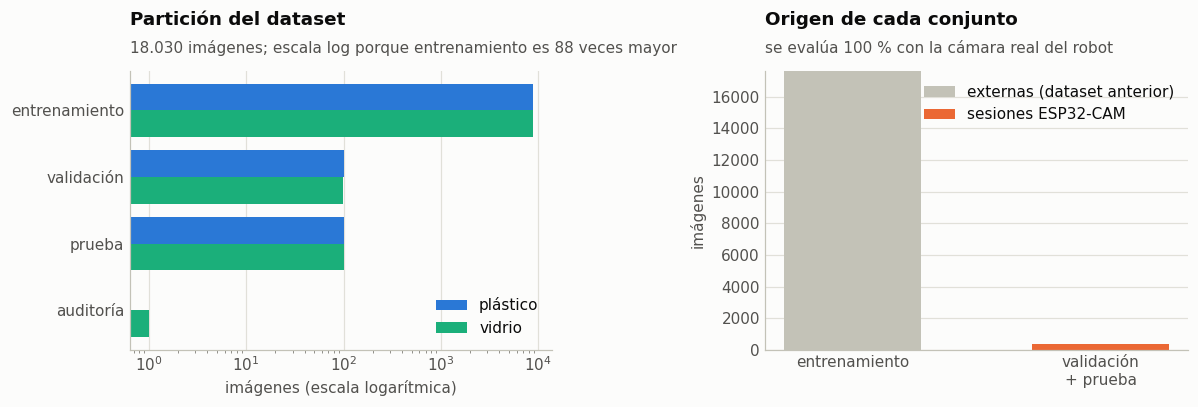

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

conjuntos = ["entrenamiento", "validación", "prueba", "auditoría"]
plastico = [8765, 100, 100, 0]
vidrio   = [8865,  99, 100, 1]
y = np.arange(len(conjuntos))

ax1.barh(y - 0.2, plastico, 0.4, label="plástico", color=AZUL)
ax1.barh(y + 0.2, vidrio,   0.4, label="vidrio",  color=AQUA)
ax1.set_yticks(y); ax1.set_yticklabels(conjuntos)
ax1.set_xscale("log"); ax1.set_xlabel("imágenes (escala logarítmica)")
ax1.invert_yaxis(); ax1.legend(loc="lower right")
limpiar(ax1, eje_y=False)
poner_titulo(ax1, "Partición del dataset",
             "18.030 imágenes; escala log porque entrenamiento es 88 veces mayor")

# Origen: entrenamiento se apoya en el dataset viejo, la evaluación no
ax2.bar(["entrenamiento", "validación\n+ prueba"], [17630, 0], 0.55,
        label="externas (dataset anterior)", color=BASE)
ax2.bar(["entrenamiento", "validación\n+ prueba"], [0, 399], 0.55,
        bottom=[17630, 0], label="sesiones ESP32-CAM", color=NARANJA)
ax2.set_ylabel("imágenes")
ax2.legend(loc="upper right")
limpiar(ax2)
poner_titulo(ax2, "Origen de cada conjunto",
             "se evalúa 100 % con la cámara real del robot")
plt.tight_layout(); plt.show()

### Lectura del resultado

La segunda gráfica contiene el dato metodológico más importante de todo el
experimento: **validación y prueba son íntegramente capturas de la ESP32-CAM.**

Es decir, todas las métricas de este cuaderno están medidas sobre el dominio
real del robot. Cuando en la sección 4 se lea «90,28 %», no es un número de
laboratorio: es la cámara que llevará puesta el robot.

Esto hace directamente comparable el resultado con el 71,60 % del cuaderno
hermano, porque ambos se midieron sobre el mismo tipo de imagen.

Contrapartida honesta: el entrenamiento sigue apoyado casi por completo en el
dataset anterior. Los modelos aprenden sobre todo de otro dominio y se evalúan
en el propio.

## 2.2. Partición inmutable

La asignación vive en `split_manifest.json` con semilla 42 y se hace **por
sesión completa**, nunca por foto suelta.

La razón: la ESP32-CAM captura ráfagas de fotos casi idénticas con dos segundos
de diferencia. Repartirlas al azar pondría la foto 001 en entrenamiento y la
002 en prueba; el modelo la reconocería de memoria y la prueba mediría memoria,
no generalización.

El cargador rechaza el dataset si detecta un SHA-256 repetido entre conjuntos,
una sesión partida en dos, una partición vacía o una clase ausente. La fuga de
datos no se evita por disciplina: se evita por construcción.

# 3. Diseño experimental

## 3.1. Procedimiento

Idéntico en las nueve corridas:

1. **Fase 1 — cabeza.** Backbone congelado, tasa `1e-3`. La capa final parte de
   valores aleatorios; entrenarla sola evita que sus errores iniciales destruyan
   los pesos heredados de ImageNet.
2. **Fase 2 — ajuste fino.** Se descongela el último 30 % del backbone con tasa
   `1e-5`, cien veces menor. Las capas de `BatchNormalization` siguen congeladas:
   con lotes pequeños, actualizar sus estadísticas desestabiliza el ajuste.
3. **Selección.** Parada temprana y mejor punto de control por **macro-F1 de
   validación**, no por exactitud.

## 3.2. Por qué macro-F1 y no exactitud

La exactitud promedia sobre las clases y puede esconder que una funciona mal.
Es exactamente lo que ocurrió con el modelo desplegado: 71,60 % global ocultaba
un recall de plástico del 60,60 %.

El macro-F1 promedia el F1 de cada clase **dando el mismo peso a ambas**, así
que una clase débil arrastra la métrica hacia abajo en lugar de diluirse.

## 3.3. Por qué tres semillas

Entrenar tiene componentes aleatorios: la inicialización de la cabeza y el
orden de los lotes. Dos corridas idénticas dan resultados algo distintos.

Con una sola corrida por arquitectura no habría forma de saber si una diferencia
es real o azar. Con tres se puede reportar media y desviación, y comprobar si
los rangos se solapan.

# 4. Resultados de validación

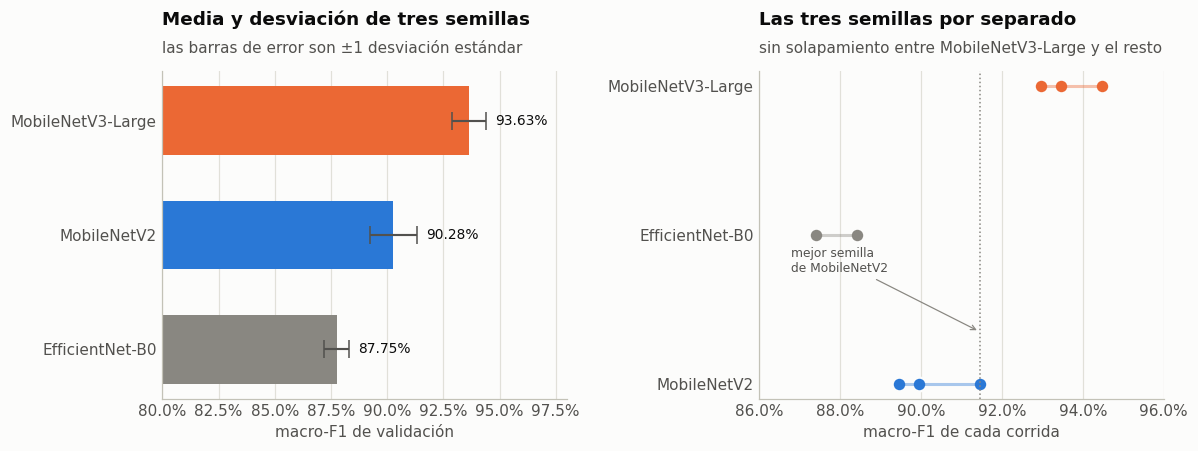

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

medias = [stat(a, "val_macro_f1") for a in ARQ]
desv   = [stat(a, "val_macro_f1", "desviacion_estandar") for a in ARQ]
orden  = np.argsort(medias)
y = np.arange(len(ARQ))

ax1.barh(y, [medias[i] for i in orden], 0.6,
         xerr=[desv[i] for i in orden], capsize=6,
         color=[COLOR[ARQ[i]] for i in orden],
         error_kw=dict(lw=1.4, ecolor=TINTA_2))
ax1.set_yticks(y); ax1.set_yticklabels([NOMBRE[ARQ[i]] for i in orden])
ax1.set_xlim(0.80, 0.98); ax1.set_xlabel("macro-F1 de validación")
ax1.xaxis.set_major_formatter(PercentFormatter(1.0))
for k, i in enumerate(orden):
    ax1.text(medias[i] + desv[i] + 0.004, k, f"{medias[i]:.2%}", va="center",
             fontsize=9, color=TINTA)
limpiar(ax1, eje_y=False)
poner_titulo(ax1, "Media y desviación de tres semillas",
             "las barras de error son ±1 desviación estándar")

# Semilla a semilla: comprobar si los rangos se solapan
for a in ARQ:
    vals = sorted(float(c["val_macro_f1"]) for c in CORRIDAS if c["arquitectura"] == a)
    ax2.plot(vals, [NOMBRE[a]] * 3, "o", color=COLOR[a], markersize=9,
             markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
    ax2.plot([vals[0], vals[-1]], [NOMBRE[a]] * 2, "-", color=COLOR[a], lw=2, alpha=0.4)
ax2.set_xlim(0.86, 0.96); ax2.set_xlabel("macro-F1 de cada corrida")
ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
ax2.axvline(0.9145, ls=":", color=APAGADO, lw=1)
ax2.annotate("mejor semilla\nde MobileNetV2", xy=(0.9145, 0.35), xytext=(0.868, 0.75),
             fontsize=8, color=TINTA_2,
             arrowprops=dict(arrowstyle="->", color=APAGADO, lw=0.8))
limpiar(ax2, eje_y=False)
poner_titulo(ax2, "Las tres semillas por separado",
             "sin solapamiento entre MobileNetV3-Large y el resto")
plt.tight_layout(); plt.show()

### Lectura del resultado

**MobileNetV3-Large gana en validación** con 93,63 % ± 0,77, y la ventaja es
sólida: su **peor** semilla (92,96 %) supera a la **mejor** de MobileNetV2
(91,45 %). Los rangos no se solapan, así que la diferencia no es ruido de
inicialización.

EfficientNet-B0 quedó último, por debajo del control. Su mayor capacidad no se
tradujo en mejor desempeño con este volumen de datos.

Pero el resultado más importante de esta gráfica es otro, y no se ve en ella:

```
MobileNetV2 de julio (mismo tipo de fotos)   →  71,60 %
MobileNetV2 reentrenado                      →  90,28 %
```

**Casi 19 puntos, sin cambiar de arquitectura.** La mejora vino de reconstruir
el dataset y de la partición honesta, no de un modelo mejor. Para eso existía el
control E1, y su respuesta es inequívoca.

Frente a esos 19 puntos ganados por datos, los 3,35 que aporta MobileNetV3-Large
son un margen modesto.

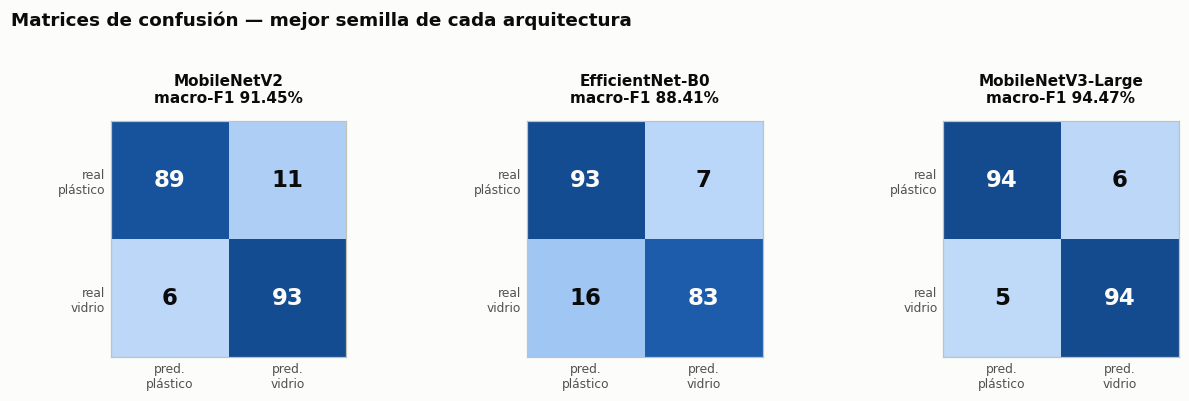

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
mejores = {a: max((c for c in CORRIDAS if c["arquitectura"] == a),
                  key=lambda c: float(c["val_macro_f1"])) for a in ARQ}

for ax, a in zip(axes, ARQ):
    m = metricas_de(mejores[a]["run_id"])
    mat = np.array(m["matriz_confusion"])
    ax.imshow(mat, cmap=CMAP_SEC, vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred.\nplástico", "pred.\nvidrio"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["real\nplástico", "real\nvidrio"], fontsize=8)
    ax.grid(False); ax.tick_params(length=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, mat[i, j], ha="center", va="center", fontsize=15,
                    weight="bold", color=SUPERFICIE if mat[i, j] > 55 else TINTA)
    ax.set_title(f"{NOMBRE[a]}\nmacro-F1 {float(mejores[a]['val_macro_f1']):.2%}",
                 fontsize=10, loc="center")
fig.suptitle("Matrices de confusión — mejor semilla de cada arquitectura",
             x=0.02, ha="left", fontsize=12, weight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

### Lectura del resultado

Las tres matrices son **casi simétricas**: los errores se reparten de forma
pareja entre las dos clases. Ninguna arquitectura tiene una clase claramente
débil.

Conviene contrastarlo con el modelo desplegado, cuya matriz sobre capturas de
ESP32-CAM era marcadamente asimétrica: acertaba el 82,6 % del vidrio y solo el
60,6 % del plástico. Esa asimetría era la firma del cambio de dominio, y **ha
desaparecido**.

Es una segunda evidencia, independiente del macro-F1, de que el problema de
dominio quedó corregido.

# 5. Comportamiento durante el entrenamiento

Las curvas muestran algo que las métricas finales no: **cómo** llegó cada
arquitectura a su resultado.

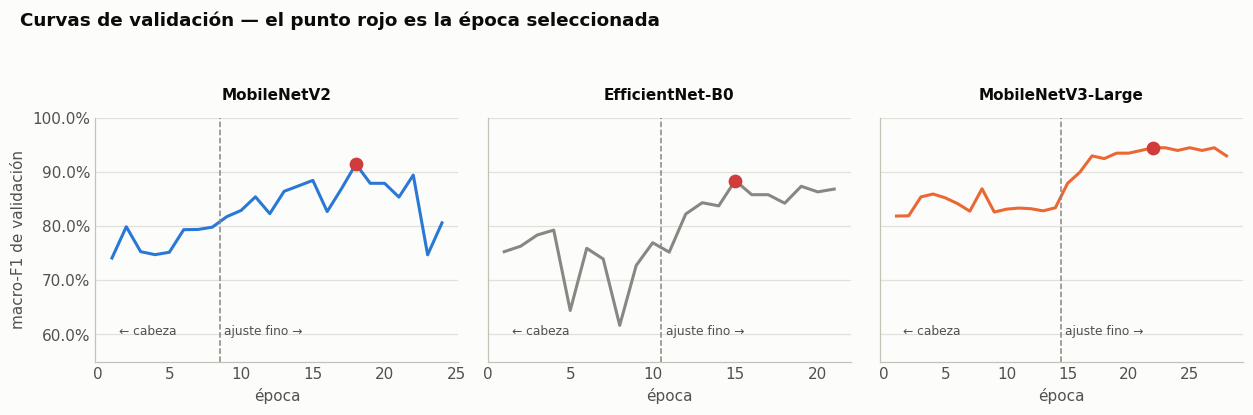

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), sharey=True)

for ax, a in zip(axes, ARQ):
    ruta = RESULTADOS / "historiales" / f"{mejores[a]['run_id']}_history.csv"
    with ruta.open(encoding="utf-8", newline="") as fh:
        h = list(csv.DictReader(fh))
    ep = [int(f["epoch"]) for f in h]
    f1 = [float(f["val_macro_f1"]) for f in h]
    corte = sum(1 for f in h if f["fase"] == "cabeza")
    ax.plot(ep, f1, "-", color=COLOR[a], lw=2)
    ax.axvline(ep[corte - 1] + 0.5, ls="--", color=APAGADO, lw=1)
    ax.text(ep[corte - 1] + 0.8, 0.60, "ajuste fino →", fontsize=8, color=TINTA_2)
    ax.text(1.5, 0.60, "← cabeza", fontsize=8, color=TINTA_2)
    mejor = int(mejores[a]["mejor_epoca"])
    ax.plot(mejor, f1[mejor - 1], "o", color=CRITICO, markersize=8, zorder=5)
    ax.set_title(NOMBRE[a], fontsize=10)
    ax.set_xlabel("época")
    ax.set_ylim(0.55, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    limpiar(ax)

axes[0].set_ylabel("macro-F1 de validación")
fig.suptitle("Curvas de validación — el punto rojo es la época seleccionada",
             x=0.02, ha="left", fontsize=12, weight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

### Lectura del resultado

El salto vertical en la línea discontinua es el paso a **ajuste fino**. Es la
justificación empírica del procedimiento de dos fases: entrenar solo la cabeza
lleva hasta cierto punto, y descongelar parte del backbone con una tasa cien
veces menor produce la mejora grande.

También se aprecia por qué hace falta parada temprana: después del pico, las
curvas se aplanan o empeoran. Seguir entrenando no habría ayudado.

Las épocas seleccionadas varían bastante entre corridas (de la 12 a la 27), lo
que confirma que fijar un número de épigrafes igual para todos habría penalizado
a unas arquitecturas frente a otras.

# 6. Verificación de cuantización (criterio 4)

## 6.1. Por qué esta sección existe

Todo lo anterior mide el modelo de **Keras en punto flotante**. Lo que se
instala en el servicio es otro archivo: un `.tflite` **cuantizado a int8**, con
los parámetros convertidos de números de 32 bits a enteros de 8.

La cuantización reduce el tamaño unas cuatro veces y acelera la inferencia. La
apuesta implícita es que un modelo entrenado tiene redundancia suficiente para
que esa pérdida de precisión numérica no cambie sus predicciones.

**Esa apuesta hay que comprobarla.** El criterio 4 de la propuesta lo exige
—«sin regresión relevante después de la exportación»— y las nueve corridas se
ejecutaron antes de que existiera la función que lo mide.

/var/folders/xm/h1xby_m52nz28_vxs78tr8vw0000gn/T/ipykernel_4025/1933954832.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([NOMBRE[a].replace("-", "-\n") for a in ARQ], fontsize=9)


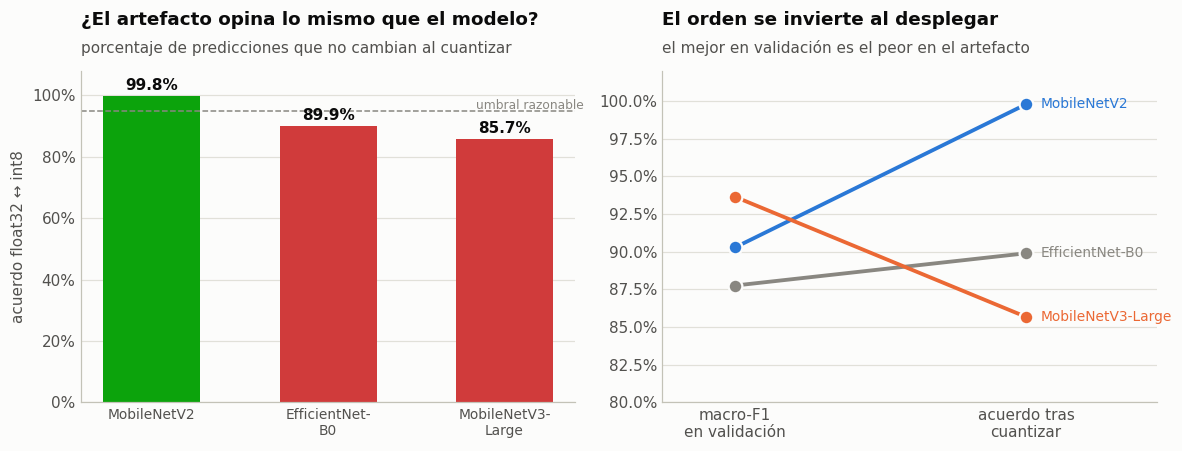

In [14]:
# Medición ejecutada sobre las nueve corridas comparando cada model.keras
# contra su model.tflite int8 sobre las mismas imágenes.
ACUERDO = {
    "mobilenetv2":       [0.9967, 0.9967, 1.0000],
    "efficientnetb0":    [0.9167, 0.9133, 0.8667],
    "mobilenetv3large":  [0.8500, 0.8567, 0.8633],
}
DESVIO_MAX = {"mobilenetv2": 0.4418, "efficientnetb0": 0.9835, "mobilenetv3large": 1.0000}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

medias_ac = [float(np.mean(ACUERDO[a])) for a in ARQ]
colores = [BUENO if m >= 0.95 else CRITICO for m in medias_ac]
barras = ax1.bar([NOMBRE[a] for a in ARQ], medias_ac, 0.55, color=colores)
ax1.axhline(0.95, ls="--", color=APAGADO, lw=1)
ax1.text(2.45, 0.955, "umbral razonable", fontsize=8, color=APAGADO, ha="right")
ax1.set_ylim(0, 1.08); ax1.set_ylabel("acuerdo float32 ↔ int8")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_xticklabels([NOMBRE[a].replace("-", "-\n") for a in ARQ], fontsize=9)
for b, m in zip(barras, medias_ac):
    ax1.text(b.get_x() + b.get_width() / 2, m + 0.02, f"{m:.1%}",
             ha="center", weight="bold", fontsize=10, color=TINTA)
limpiar(ax1)
poner_titulo(ax1, "¿El artefacto opina lo mismo que el modelo?",
             "porcentaje de predicciones que no cambian al cuantizar")

# Lo que se gana en validación frente a lo que se conserva al desplegar
for a in ARQ:
    ax2.plot([0, 1], [stat(a, "val_macro_f1"), float(np.mean(ACUERDO[a]))],
             "o-", color=COLOR[a], lw=2.5, markersize=9,
             markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=NOMBRE[a])
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["macro-F1\nen validación", "acuerdo tras\ncuantizar"])
ax2.set_xlim(-0.25, 1.45); ax2.set_ylim(0.80, 1.02)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
for a in ARQ:
    ax2.text(1.05, float(np.mean(ACUERDO[a])), NOMBRE[a], fontsize=9,
             va="center", color=COLOR[a])
limpiar(ax2)
poner_titulo(ax2, "El orden se invierte al desplegar",
             "el mejor en validación es el peor en el artefacto")
plt.tight_layout(); plt.show()

### Lectura del resultado

El resultado invierte la conclusión de la sección 4:

| Arquitectura | Acuerdo f32 ↔ int8 | ¿Cumple el criterio 4? |
| --- | ---: | --- |
| MobileNetV2 | **99,78 %** | **Sí** |
| EfficientNet-B0 | 89,89 % | No |
| MobileNetV3-Large | **85,67 %** | **No** |

MobileNetV3-Large **cambia de respuesta en una de cada siete imágenes** al
cuantizarse. Su desvío máximo de probabilidad es `1,0000`: existen imágenes
donde la versión float32 elige una clase con total seguridad y la int8 elige la
contraria, también con total seguridad.

El resultado es consistente en las tres semillas de cada arquitectura, así que
no es un artefacto de una corrida concreta.

### La causa: la activación

Vuelve a la tabla de la sección 1.2, a la fila que parecía un detalle menor.

Cuantizar a int8 significa repartir 256 valores posibles sobre el rango que las
activaciones puedan tomar. **ReLU6 está acotada entre 0 y 6**: esos 256 valores
cubren un intervalo pequeño y quedan finos. Swish y hard-swish no tienen cota
superior, así que hay que estirar los mismos 256 valores sobre un rango amplio
y cada escalón se vuelve grueso.

ReLU6 no lleva ese 6 por casualidad: MobileNetV2 se diseñó pensando en
cuantizar.

### Salvedad metodológica

Esta medición se ejecutó con imágenes del conjunto de entrenamiento, porque las
de validación no estaban disponibles en la máquina donde se hizo.

El **acuerdo** no se ve afectado por ello: compara dos versiones del mismo
modelo sobre las mismas fotos y no depende de las etiquetas ni de si el modelo
las vio antes. La caída de macro-F1 sí queda optimista, por lo que no se reporta
aquí como cifra de decisión. Conviene repetir la medición con las 199 imágenes
de validación antes de cerrar la elección.

# 7. Criterios de aceptación y recomendación

## 7.1. Evaluación formal

La propuesta fijó cinco criterios **antes** de ver los resultados, que es la
única forma de que un criterio signifique algo:

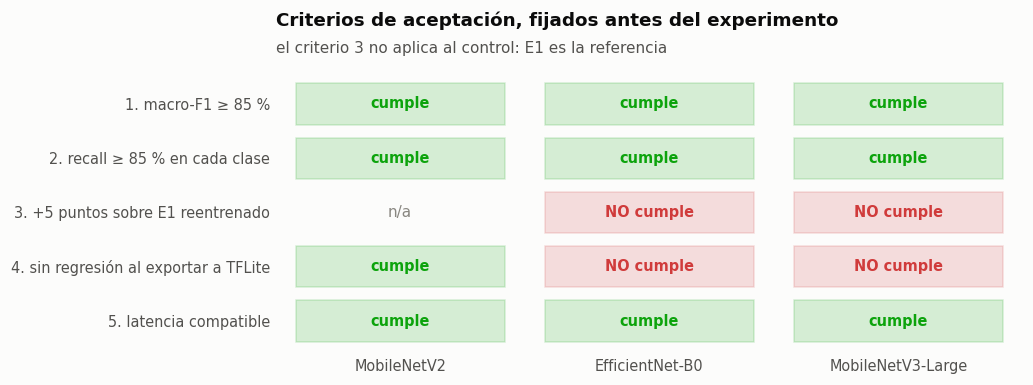

In [15]:
criterios = [
    ("1. macro-F1 ≥ 85 %",                    [True,  True,  True]),
    ("2. recall ≥ 85 % en cada clase",        [True,  True,  True]),
    ("3. +5 puntos sobre E1 reentrenado",     [None,  False, False]),
    ("4. sin regresión al exportar a TFLite", [True,  False, False]),
    ("5. latencia compatible",                [True,  True,  True]),
]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for fila, (nombre, estados) in enumerate(criterios):
    for col, ok in enumerate(estados):
        if ok is None:
            ax.text(col, fila, "n/a", ha="center", va="center", fontsize=10, color=APAGADO)
            continue
        ax.add_patch(plt.Rectangle((col - 0.42, fila - 0.38), 0.84, 0.76,
                                   color=BUENO if ok else CRITICO, alpha=0.16))
        ax.text(col, fila, "cumple" if ok else "NO cumple", ha="center", va="center",
                fontsize=9.5, weight="bold", color=BUENO if ok else CRITICO)

ax.set_xticks(range(3)); ax.set_xticklabels([NOMBRE[a] for a in ARQ], fontsize=9.5)
ax.set_yticks(range(len(criterios)))
ax.set_yticklabels([c[0] for c in criterios], fontsize=9.5)
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.6, len(criterios) - 0.4)
ax.invert_yaxis(); ax.grid(False); ax.tick_params(length=0)
for lado in ("top", "right", "left", "bottom"):
    ax.spines[lado].set_visible(False)
poner_titulo(ax, "Criterios de aceptación, fijados antes del experimento",
             "el criterio 3 no aplica al control: E1 es la referencia")
plt.tight_layout(); plt.show()

### Lectura actualizada: experimento frente a despliegue

Las nueve corridas siguen siendo evidencia válida de proceso: V3-Large
lideró la **validación Keras** y MobileNetV2 fue la alternativa más
compacta. Sin embargo, esos resultados no decidieron el robot.

La comparación posterior de los dos artefactos disponibles con 1.000
capturas OV3660/QVGA eligió **MobileNetV2 TFLite float32**: 71,60 % de
exactitud y 71,25 % de macro-F1, frente a 57,10 % y 57,09 % de
MobileNetV3-Large INT8. El V3 se conserva como respaldo sin voto.

Ninguno de estos conjuntos se presenta como prueba reservada final.
La lección para la feria es precisa: se debe medir el modelo exportado
con la cámara real antes de declararlo apto para el robot.
